# Sustainable Tourism Recommender Evaluation
This notebook reports a paired agent-based experiment comparing popularity, personalized, and sustainability-aware recommendations in Barcelona.

## Methodology and assumptions
Each replication generates the same synthetic tourist population for all strategies. Tourists make four visits over six time slots. POI identities and approximate locations are real; capacity, popularity, sustainability, and local-economic attributes are modeled for evaluation.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
metrics = pd.read_csv(root / 'outputs' / 'run_metrics.csv')
statistics = pd.read_csv(root / 'outputs' / 'paired_statistics.csv')
metrics.groupby('strategy').mean(numeric_only=True).round(4)

,replication,seed,population,peak_load_ratio,overcrowded_poi_time_pct,top_10_visit_share,visit_gini,district_entropy,catalog_coverage,tourist_satisfaction,...,mean_distance_km,budget_compliance,precision_at_5,recall_at_5,diversity,novelty,exposure_fairness,mean_sustainability,mean_local_economic,completed_visit_share
strategy,,,,,,,,,,,,,,,,,,,,,
personalized,14.5,1014.5,5000.0,0.6916,0.0000,0.1365,0.3583,0.9746,0.9739,0.7873,...,2.5895,1.0,0.7052,0.5713,0.3333,0.5406,0.6417,0.8065,0.7201,1.0
popularity,14.5,1014.5,5000.0,1.3850,1.6667,0.7771,0.8560,0.6985,0.3983,0.5309,...,1.7090,1.0,0.1531,0.1499,0.8927,0.1804,0.1440,0.6780,0.6062,1.0
sustainability,14.5,1014.5,5000.0,0.6754,0.0000,0.0767,0.4082,1.0000,0.9728,0.7177,...,2.3975,1.0,0.4238,0.3248,0.8795,0.5685,0.5918,0.8202,0.7458,1.0


## Paired statistical comparisons

In [2]:
statistics.sort_values(['metric', 'strategy']).reset_index(drop=True)

,strategy,baseline,metric,mean_difference,ci_95_low,ci_95_high,cohens_dz,p_value
0,personalized,popularity,budget_compliance,0.000000,0.000000,0.000000,0.000000e+00,NaN
1,sustainability,popularity,budget_compliance,0.000000,0.000000,0.000000,0.000000e+00,NaN
2,personalized,popularity,catalog_coverage,0.575556,0.569957,0.581154,3.838944e+01,1.017121e-47
3,sustainability,popularity,catalog_coverage,0.574444,0.569346,0.579543,4.206806e+01,7.170686e-49
4,personalized,popularity,completed_visit_share,0.000000,0.000000,0.000000,0.000000e+00,NaN
5,sustainability,popularity,completed_visit_share,0.000000,0.000000,0.000000,0.000000e+00,NaN
6,personalized,popularity,district_entropy,0.276155,0.267615,0.284695,1.207498e+01,3.455681e-33
7,sustainability,popularity,district_entropy,0.301508,0.292989,0.310027,1.321554e+01,2.561032e-34
8,personalized,popularity,diversity,-0.559326,-0.560465,-0.558187,-1.834089e+02,2.061316e-67
9,sustainability,popularity,diversity,-0.013173,-0.013706,-0.012639,-9.221953e+00,8.030959e-30


## Main findings
Across 30 paired replications, the popularity baseline reached a mean peak load of **1.385** times comfortable capacity, versus **0.675** for the sustainability-aware strategy. The share of visits assigned to the ten most popular POIs fell from **77.7%** to **7.7%**, while normalized district entropy rose from **0.698** to **1.000**. Mean modeled tourist satisfaction increased from **0.531** to **0.718**. These are simulation outcomes under synthetic assumptions, not causal estimates for Barcelona.

## Visual evidence

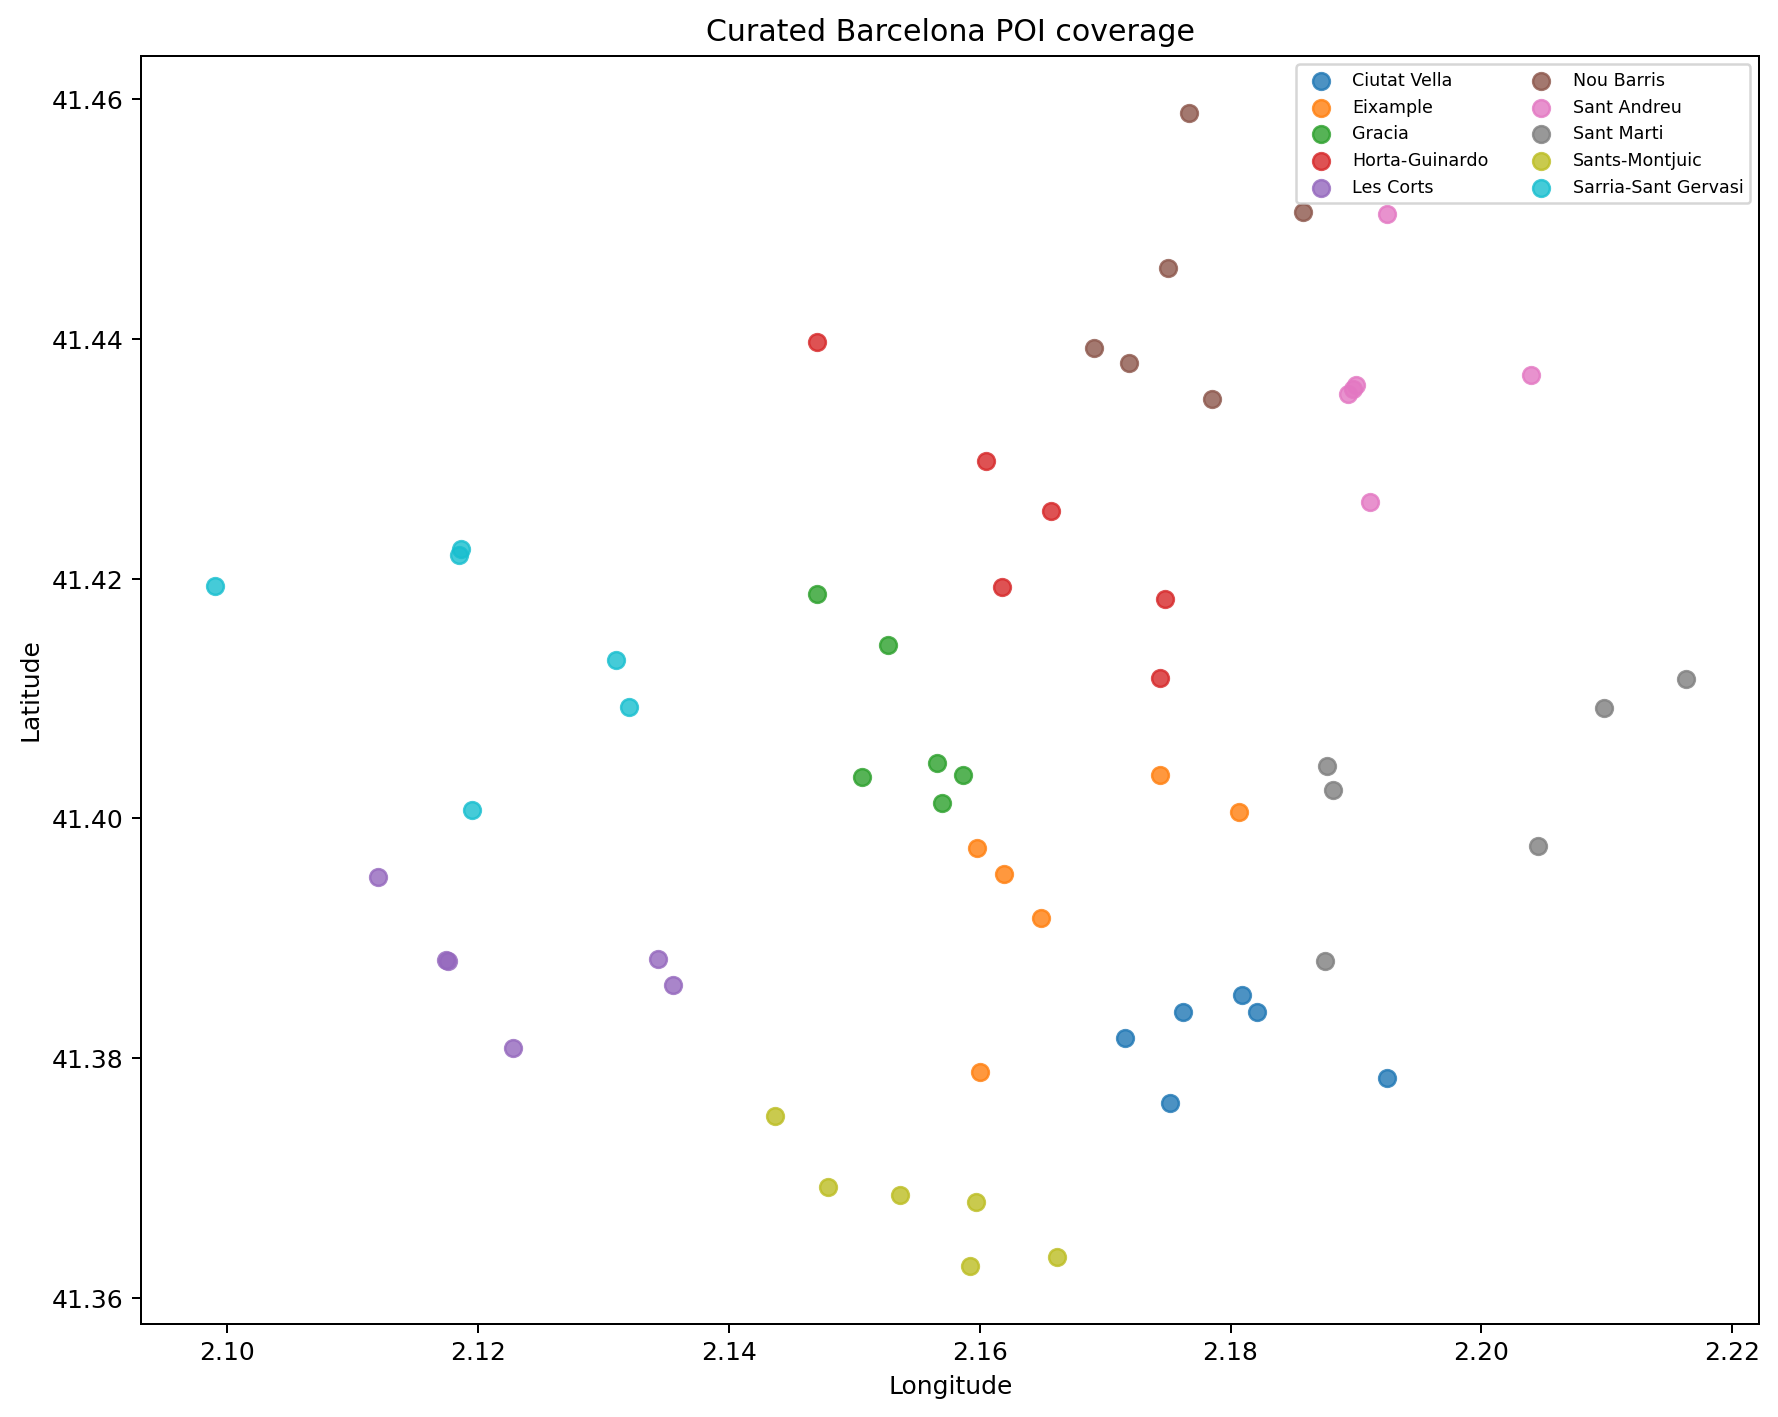

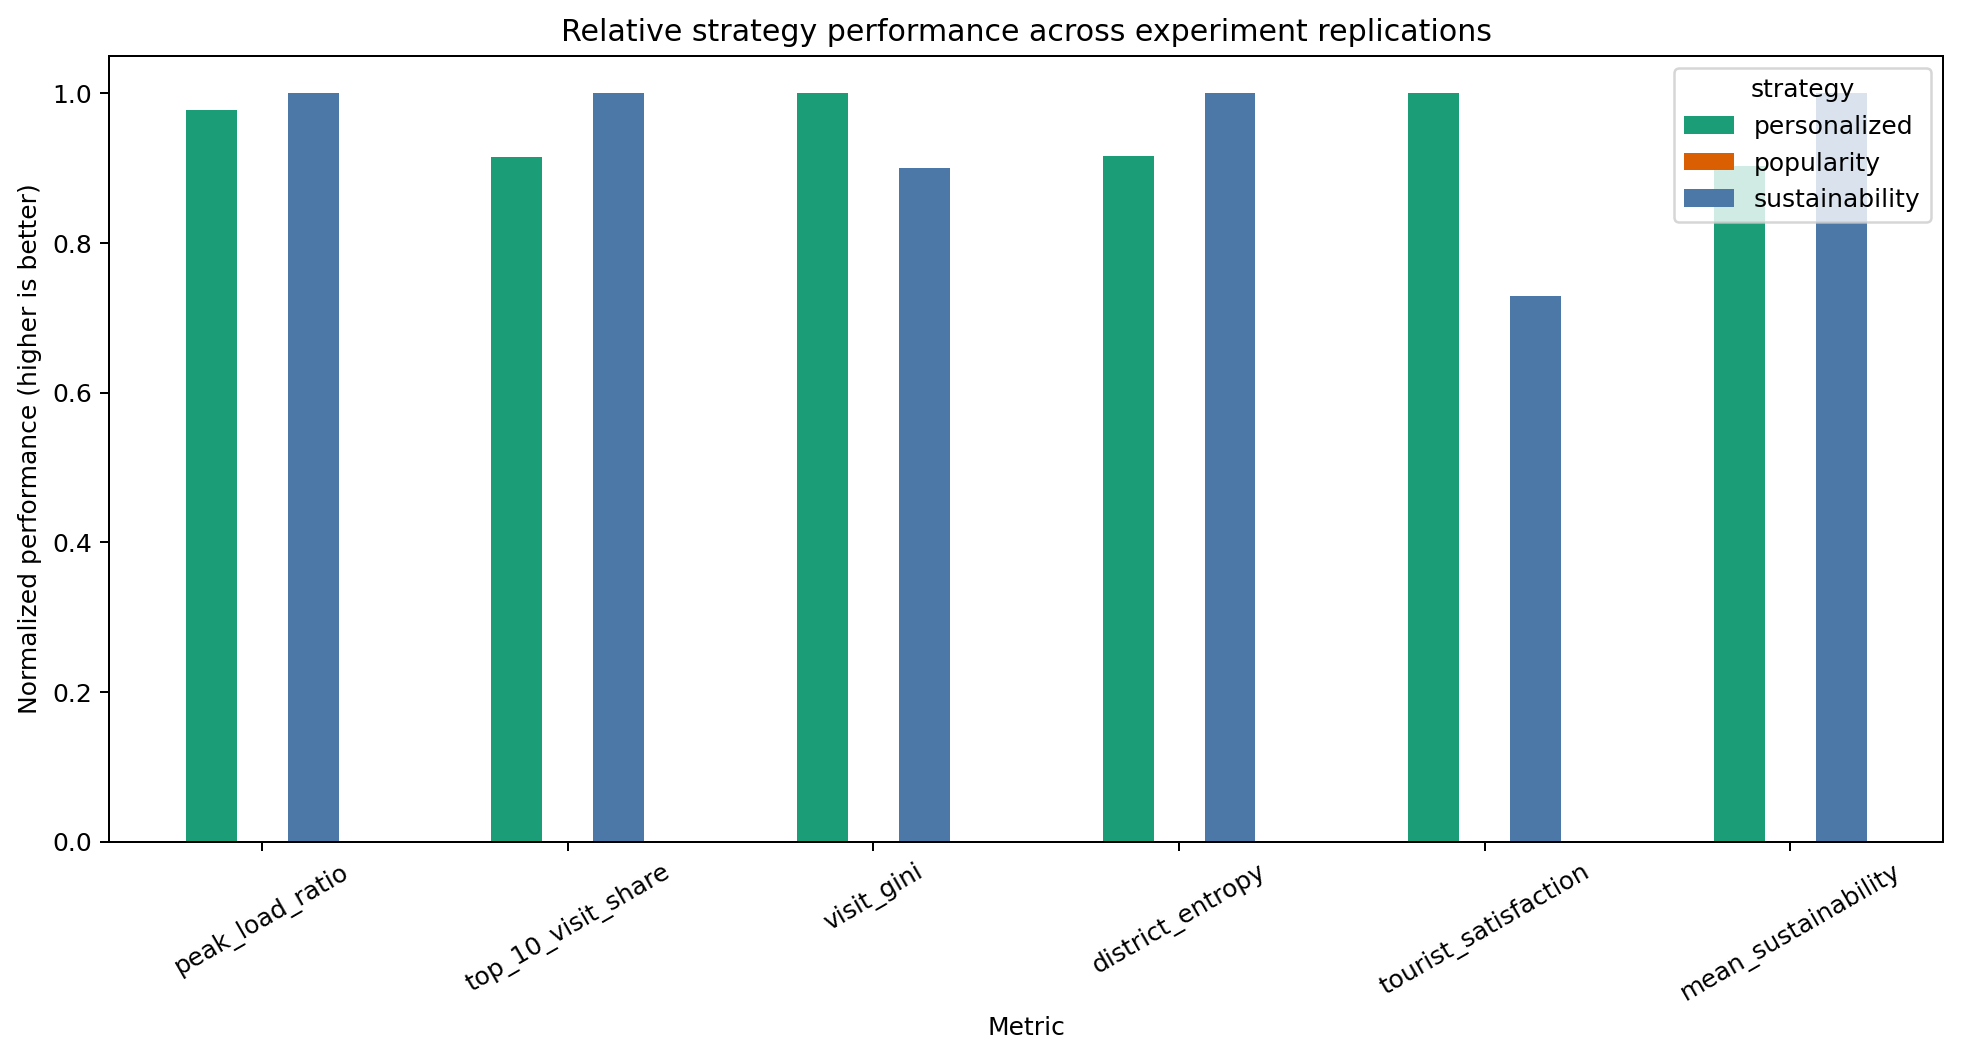

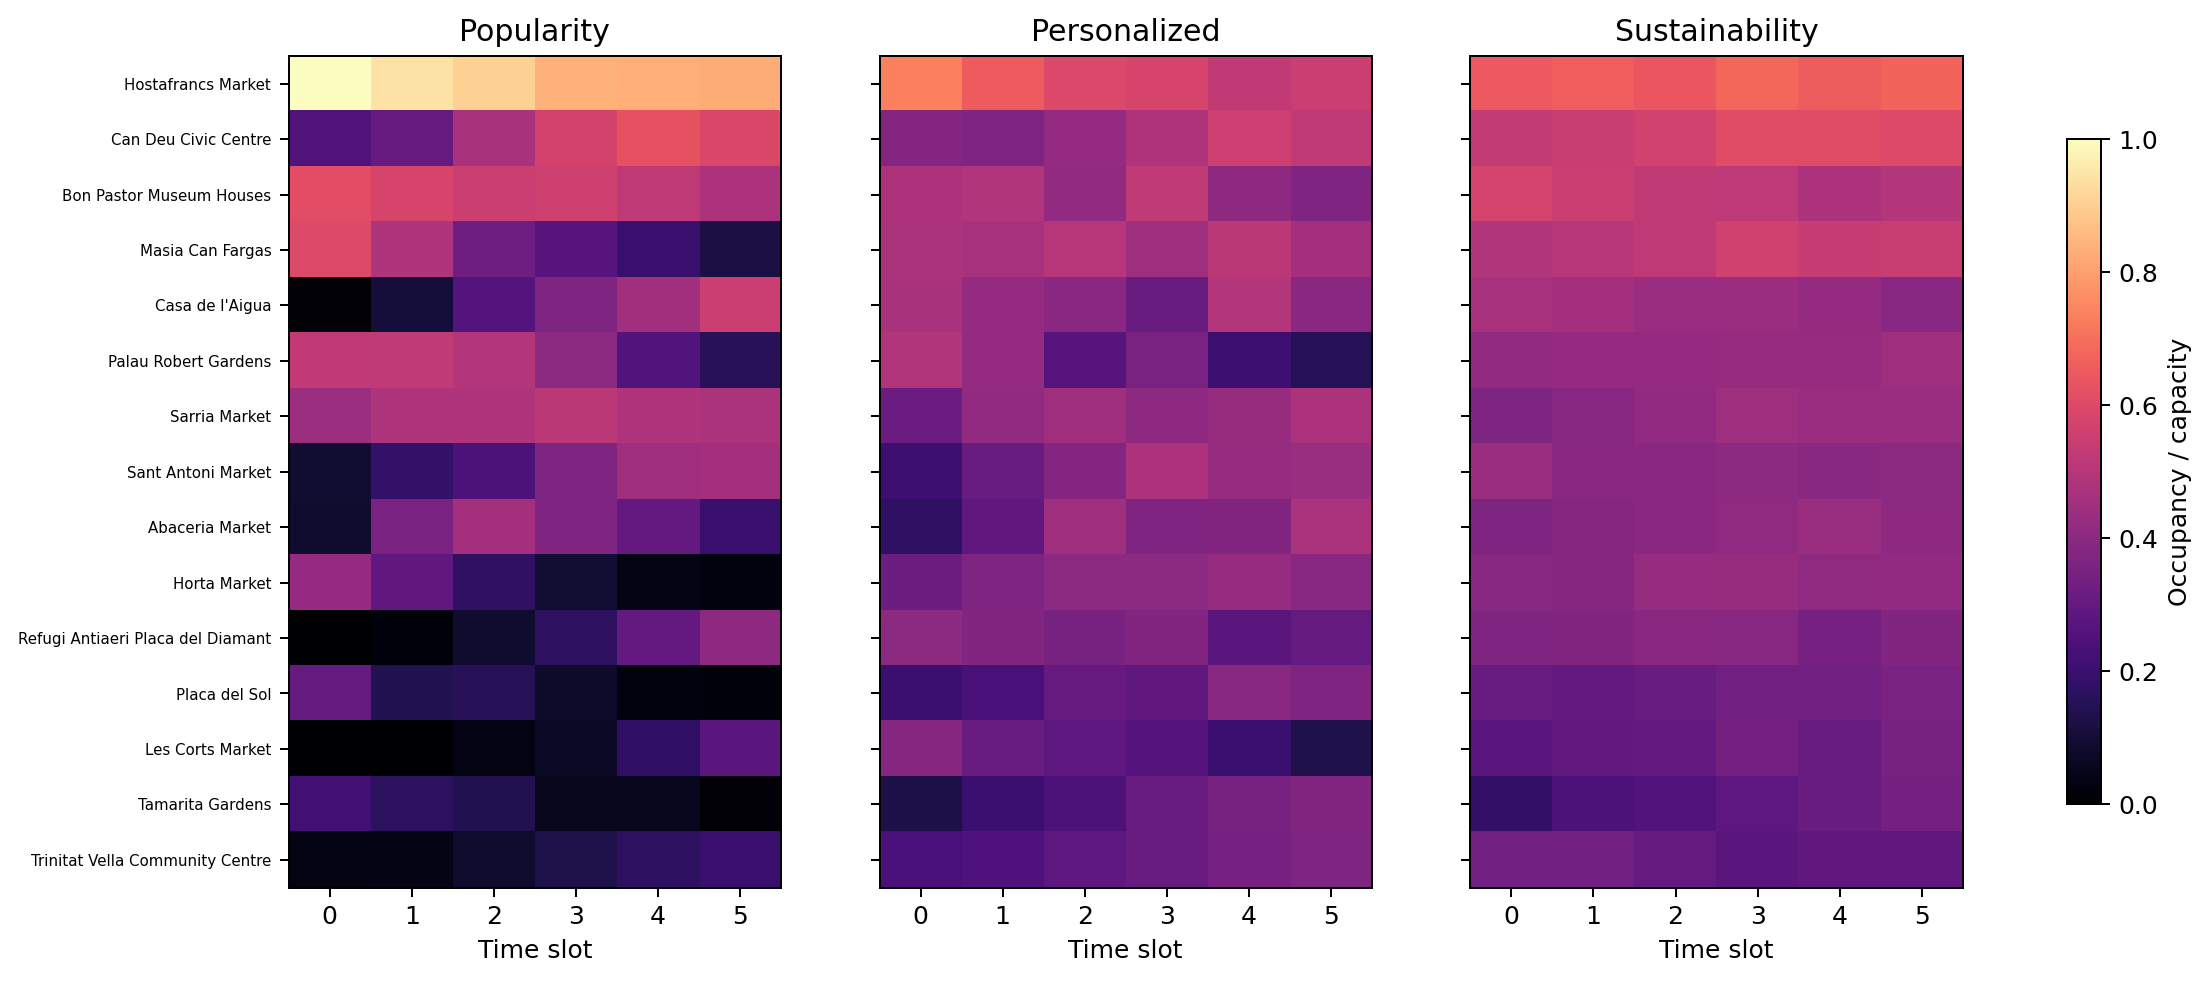

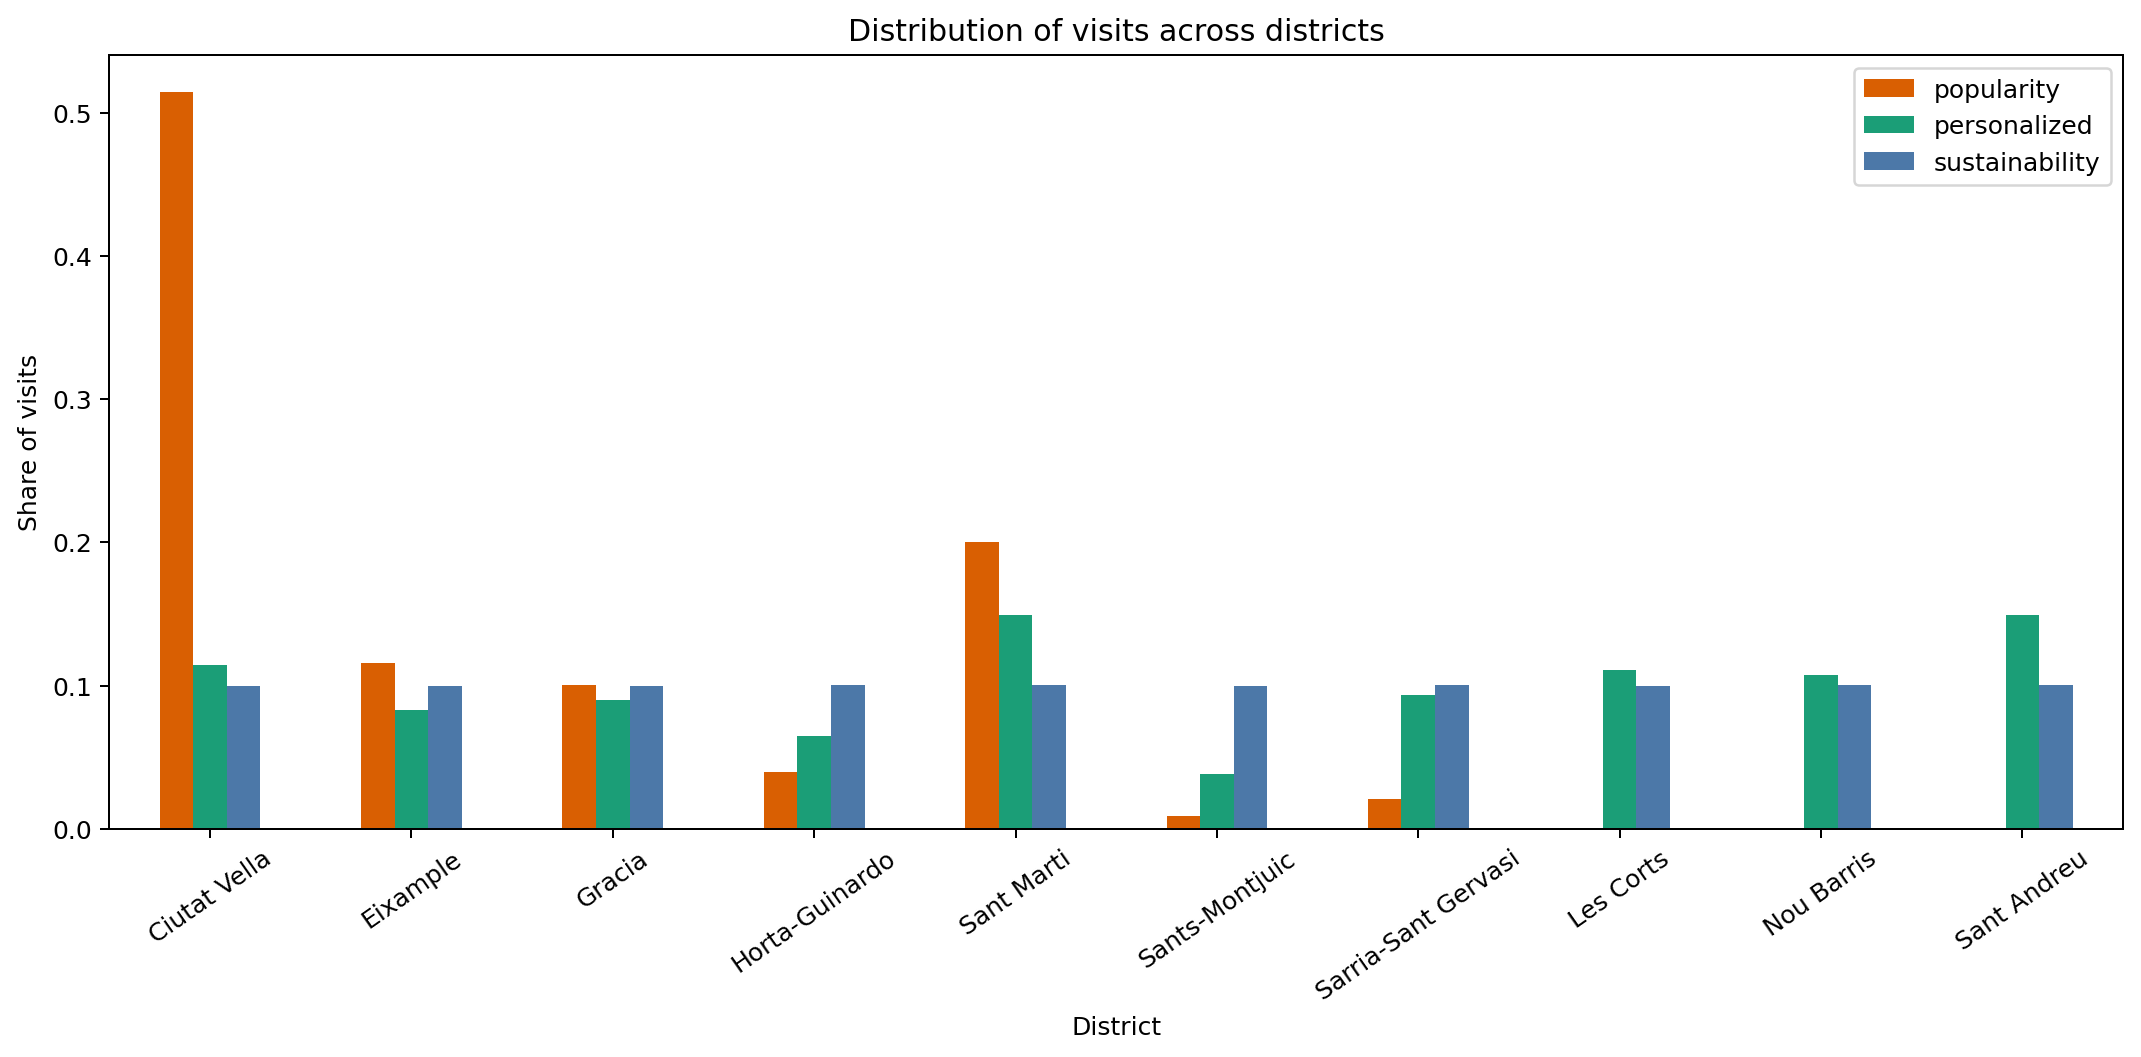

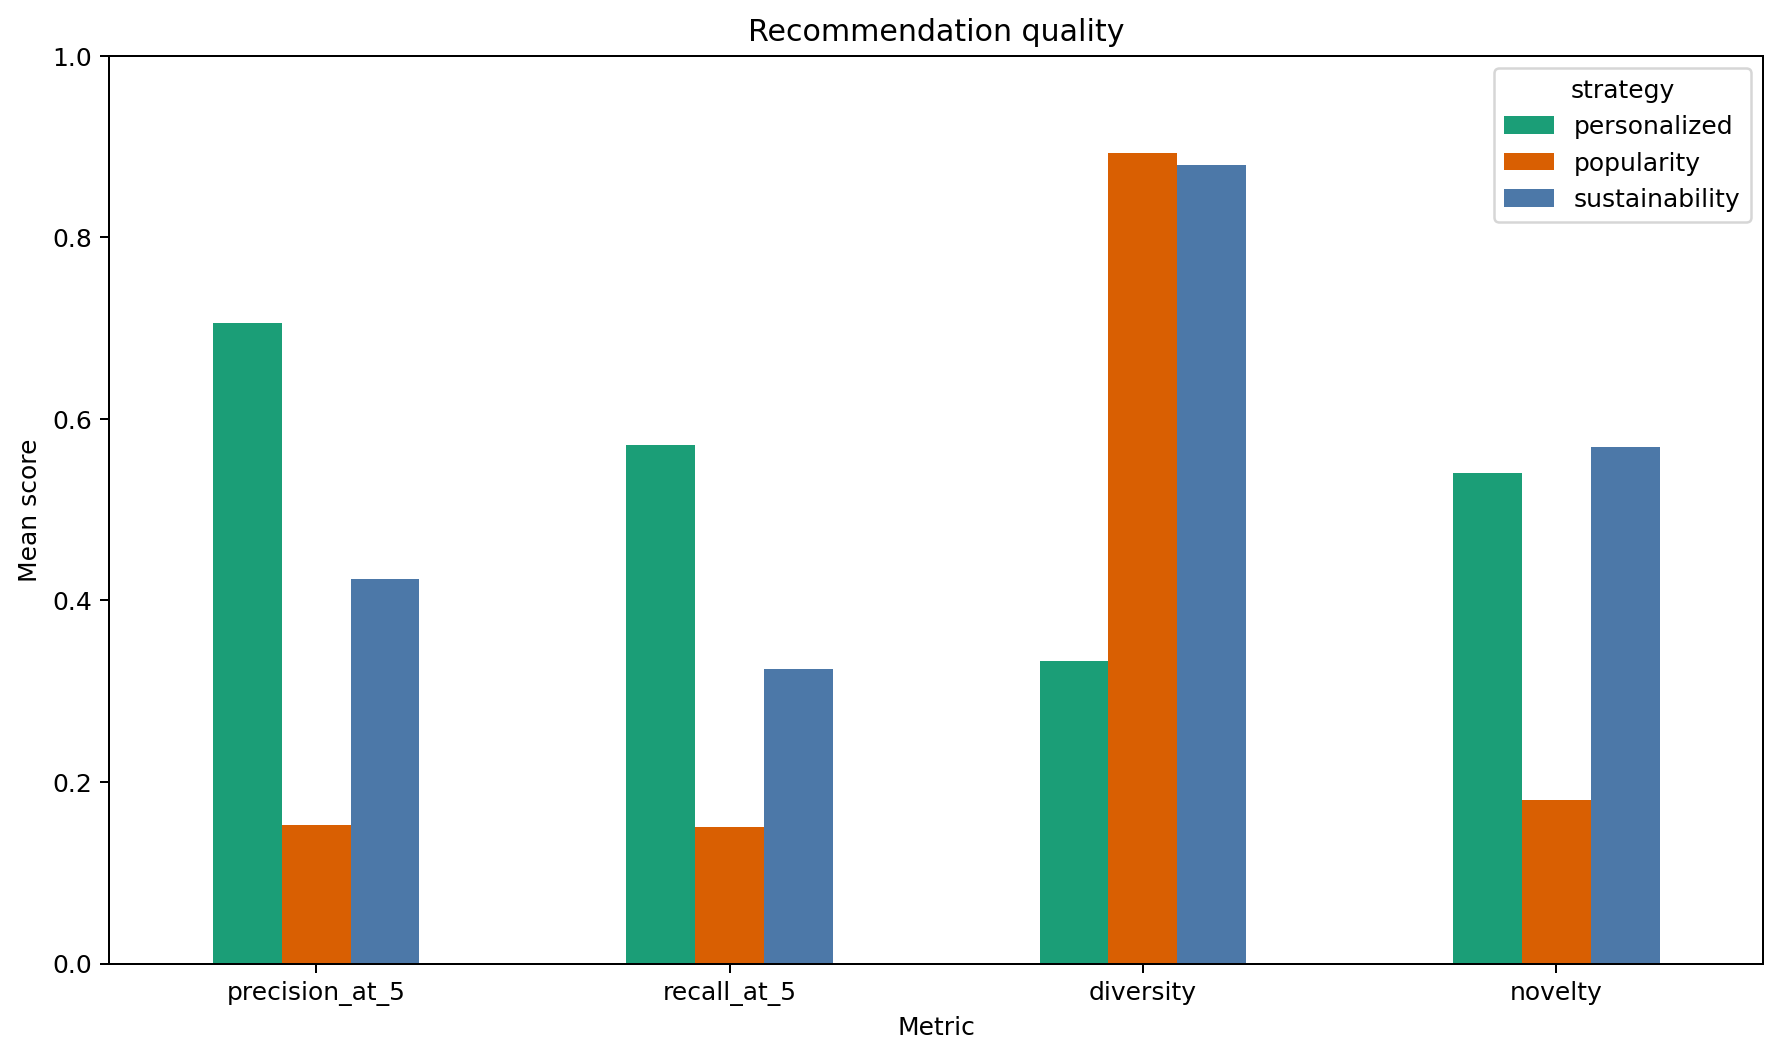

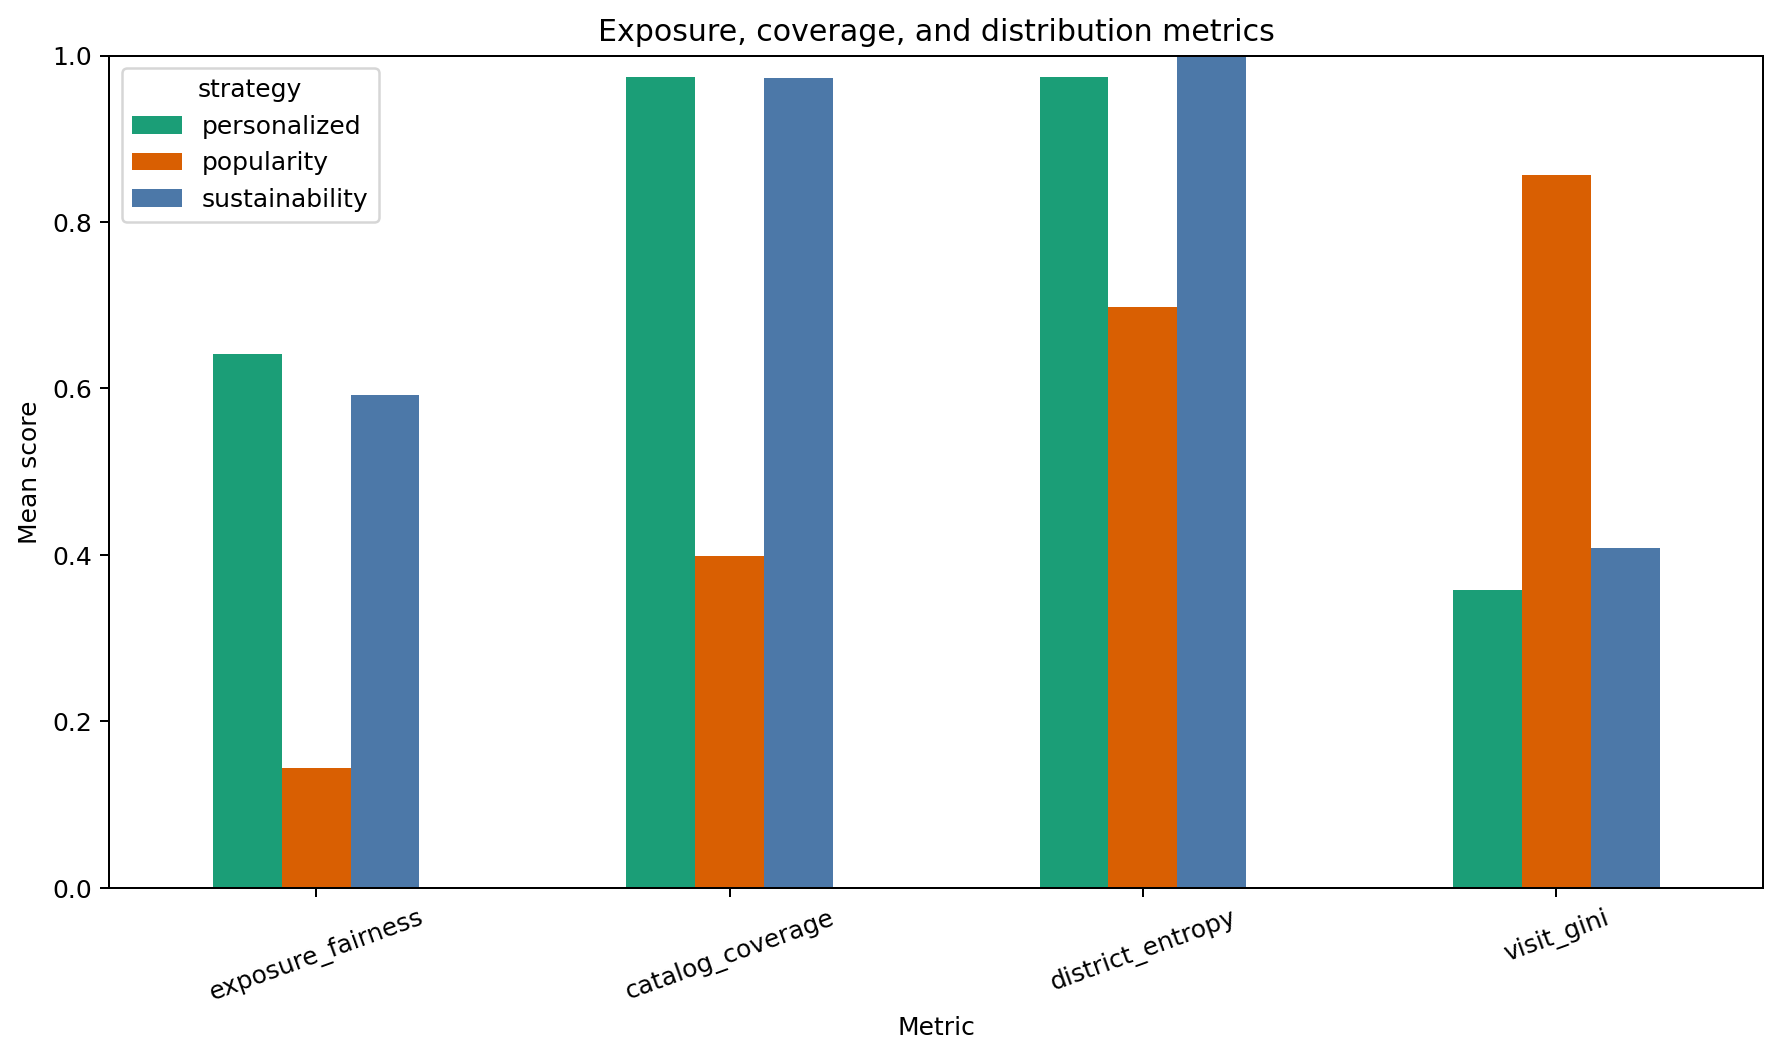

In [3]:
for name in ['poi_coverage.png', 'strategy_comparison.png', 'crowding_heatmap.png', 'district_distribution.png', 'recommendation_quality.png', 'fairness.png']:
    display(Image(filename=str(root / 'outputs' / 'figures' / name), width=900))

## Interpretation and limitations
The sustainability-aware strategy is evaluated on whether it reduces concentration and peak crowding without an unacceptable loss in satisfaction or relevance. Results are evidence about this modeled scenario, not causal estimates for real Barcelona. Capacities and sustainability attributes require calibration with operational data before policy use. The model also abstracts opening hours, queues, public-transport congestion, resident behavior, weather, and seasonal demand.

## References
- Mesa documentation: https://mesa.readthedocs.io/
- Streamlit documentation: https://docs.streamlit.io/
- Barcelona Open Data portal: https://opendata-ajuntament.barcelona.cat/